# Example: Working on Tian sc Celseq2 5cl p1

**Install GraphHDBSCAN package**

Install dependency:

```bash
!pip install git+https://github.com/Campello-Lab/GraphHDBSCAN.git
```

In [2]:
from coresg_graphhdbscan import GraphCoreSGHDBSCAN

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


**Load Data**

In [4]:
import yaml
import scanpy as sc
# Load the YAML configuration file
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

Tian_config = config["DATASETS"]["Tian"]
expected_cell_label = Tian_config["cell_labels"]

# Load the AnnData object
adata = sc.read_h5ad("/content/Tian-sc_Celseq2_5cl_p1.h5ad")
# Print available columns in adata.obs
available_columns = list(adata.obs.columns)
print("Available columns in adata.obs:", available_columns)

cell_label_key = expected_cell_label

# Extract the count matrix and cell labels
count_matrix = adata.X  # Cells as rows and genes as columns
true_labels = adata.obs[cell_label_key]

Available columns in adata.obs: ['unaligned', 'aligned_unmapped', 'mapped_to_exon', 'mapped_to_intron', 'ambiguous_mapping', 'mapped_to_ERCC', 'mapped_to_MT', 'number_of_genes', 'total_count_per_cell', 'non_ERCC_percent', 'non_mt_percent', 'non_ribo_percent', 'batch', 'outliers', 'cell_number', 'cell_line_demuxlet', 'demuxlet_cls', 'n_genes', 'norm_factor']


**Clustering**

In [5]:
g = GraphCoreSGHDBSCAN(
    min_samples=range(2,30),
    sim_graph_method="sc_gauss",
    n_neighbors=16,
    no_noise=True,
    metric="euclidean",
)


In [6]:
g.fit(adata.X)

[CORE-SG] (precomputed) CORE-SG graph has 5208 edges
[CORE-SG] m= 2: MST+tree+labels in 0.0136s
[CORE-SG] m= 3: MST+tree+labels in 0.0086s
[CORE-SG] m= 4: MST+tree+labels in 0.0080s
[CORE-SG] m= 5: MST+tree+labels in 0.0080s
[CORE-SG] m= 6: MST+tree+labels in 0.0076s
[CORE-SG] m= 7: MST+tree+labels in 0.0071s
[CORE-SG] m= 8: MST+tree+labels in 0.0068s
[CORE-SG] m= 9: MST+tree+labels in 0.0069s
[CORE-SG] m=10: MST+tree+labels in 0.0074s
[CORE-SG] m=11: MST+tree+labels in 0.0070s
[CORE-SG] m=12: MST+tree+labels in 0.0070s
[CORE-SG] m=13: MST+tree+labels in 0.0071s
[CORE-SG] m=14: MST+tree+labels in 0.0069s
[CORE-SG] m=15: MST+tree+labels in 0.0075s
[CORE-SG] m=16: MST+tree+labels in 0.0073s
[CORE-SG] m=17: MST+tree+labels in 0.0081s
[CORE-SG] m=18: MST+tree+labels in 0.0074s
[CORE-SG] m=19: MST+tree+labels in 0.0078s
[CORE-SG] m=20: MST+tree+labels in 0.0070s
[CORE-SG] m=21: MST+tree+labels in 0.0067s
[CORE-SG] m=22: MST+tree+labels in 0.0069s
[CORE-SG] m=23: MST+tree+labels in 0.0085s
[

GraphCoreSGHDBSCAN(min_samples_list=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29], metric='euclidean', eps=1e-12, min_cluster_size=None, X_=None, N_=None, D_=None, core_={}, kmax_=None, edges_ut_=None, idx_with_self_=None, dst_with_self_=None, idx_no_self_=None, dst_no_self_=None, A_knn_=None, msts_={}, mst_times_={}, models_={}, times_={})

## Condensed tree

The static condensed tree below is guaranteed to render in the built documentation. As an example condensed tree with min_samples = 18 is plotted.

The widget is also shown for live notebook use. In the rendered HTML docs, widget. You can also plot this intractable condensed tree using: g.interactive_condensed_tree()

Interactivity may be limited because there is no live Python kernel behind the page.


<Axes: title={'center': 'Condensed Tree for m = 18'}, ylabel='$\\lambda$ value'>

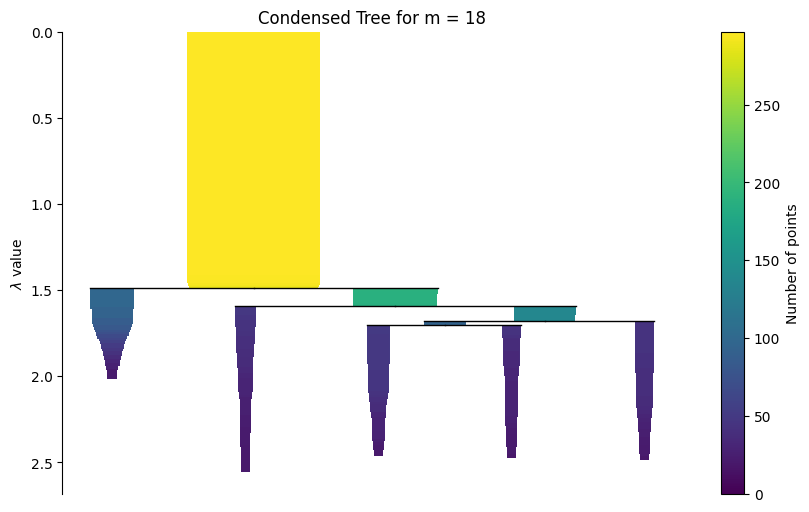

In [7]:
g.plot_condensed_tree(18)

Intractable condensed tree

In [8]:
widget = g.interactive_condensed_tree()
widget

SelectionSlider(continuous_update=False, description='m', layout=Layout(width='500px'), options=(2, 3, 4, 5, 6…

Labels for min_samples = 18

In [9]:
labels_ = g.labels_for(18)

**Evaluation**

Install dependency:

```bash
!pip install genieclust
```

In [11]:
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score
from sklearn.preprocessing import LabelEncoder
# Import the pair_sets_index function as PSI from genieclust.compare_partitions
from genieclust.compare_partitions import pair_sets_index as PSI

def evaluate_clustering(true_labels, predicted_labels):
    """
    Compute Adjusted Mutual Information (NMI), Adjusted Rand Index (ARI),
    and Pair Set Index (PSI) between true and predicted cluster labels.

    Since PSI (pair set index) expects numeric labels, we convert the input
    labels from strings (if necessary) to integers using LabelEncoder.
    """
    # Compute AMI and ARI directly; these metrics accept string labels.
    ami = adjusted_mutual_info_score(true_labels, predicted_labels)
    ari = adjusted_rand_score(true_labels, predicted_labels)

    # Use a single LabelEncoder fitted on the union of all labels to ensure consistent encoding.
    all_labels = list(set(true_labels) | set(predicted_labels))
    encoder = LabelEncoder()
    encoder.fit(all_labels)

    # Transform true and predicted labels into numeric values.
    true_labels_numeric = encoder.transform(true_labels)
    predicted_labels_numeric = encoder.transform(predicted_labels)

    # Calculate the Pair Set Index (PSI) using the numeric labels.
    psi = PSI(true_labels_numeric, predicted_labels_numeric)

    return ami, ari, psi


ami, ari, psi = evaluate_clustering(true_labels, labels_)
print("Precomputed matrix mode:")
print("AMI:", ami)
print("ARI:", ari)
print("PSI:", psi)


Precomputed matrix mode:
AMI: 0.9481596830161236
ARI: 0.9648083495818396
PSI: 0.9673381405103447
